# 03. Machine Learning Models: Random Forest & XGBoost Walk-Forward
**Models:** Random Forest (500 trees)  ·  XGBoost (early stopping)  
**Features:** 31 predictors from `data/processed/features.csv` (all look-ahead-free)  
**Assets:** 18  |  **Test period:** Jan 2018 – Dec 2025  |  **Horizon:** 1-day ahead  
**Output:** `data/processed/forecasts_rf.csv`  ·  `forecasts_xgb.csv`  ·  `results/feature_importance.csv`

In [1]:
import sys, os, warnings
# Prevent xgboost/PyTorch OpenMP deadlock on macOS (must be set before C extensions load).
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.utils.parallel import Parallel, delayed  # avoids sklearn config warning in workers

from src.data import load_and_clean, ASSETS
from src.models import RandomForestModel, XGBoostModel, LSTMModel, GARCHHybridModel
from src.evaluation import evaluate_forecasts, regime_evaluation, forecast_vs_iv_accuracy

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

PROCESSED = '../data/processed'
FIGDIR    = '../results/figures'
os.makedirs(FIGDIR, exist_ok=True)

REFIT_DATES = pd.date_range('2017-12-31', '2025-12-31', freq='ME')
print(f"Refit dates: {len(REFIT_DATES)}  ({REFIT_DATES[0].date()} – {REFIT_DATES[-1].date()})")

Refit dates: 97  (2017-12-31 – 2025-12-31)


## Load feature matrix

In [2]:
features_df = pd.read_csv(os.path.join(PROCESSED, 'features.csv'),
                           index_col=0, parse_dates=True)

FEATURE_COLS = [c for c in features_df.columns if c not in ('ticker', 'rv_21d')]

print(f"Features matrix: {features_df.shape}")
print(f"Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Tickers: {sorted(features_df['ticker'].unique())}")

# Realized vol matrix for building targets (same as GARCH notebook)
rv_all = pd.read_csv(os.path.join(PROCESSED, 'realized_vol.csv'),
                      index_col=0, parse_dates=True)

Features matrix: (70956, 33)
Feature columns (31): ['rv_lag1', 'rv_lag10', 'rv_lag20', 'rv_lag60', 'rv_ma60', 'rv_momentum_5_20', 'ret_lag1', 'absret_lag1', 'ret_lag2', 'absret_lag2', 'ret_lag3', 'absret_lag3', 'ret_lag5', 'absret_lag5', 'ret_skew_20', 'ret_kurt_20', 'max_abs_ret_20', 'ret_sq_lag1', 'hl_range', 'hl_range_ma5', 'volume_ratio', 'gap_freq_20', 'dow_0', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'vix_level', 'vix_change', 'spy_rv', 'rv_lag5']
Tickers: ['AAPL', 'AMZN', 'BAC', 'CAT', 'CVX', 'GS', 'HD', 'IWM', 'JNJ', 'JPM', 'MSFT', 'NVDA', 'PFE', 'QQQ', 'SPY', 'UNH', 'WMT', 'XOM']


## Walk-forward implementation

At each monthly refit date **T**:
1. Train on all feature rows dated ≤ T (expanding window)
2. Forecast using the feature row **at** T — this uses only data through T−1 (features are all lagged by 1 day in `engineer_features`)
3. Compare against `rv_21d` at T+1, T+5, T+20 (same targets as GARCH baseline)

In [3]:
def walk_forward_ml(ticker: str, model_name: str) -> pd.DataFrame:
    """Walk-forward ML forecasting for one ticker. Returns rows matching GARCH forecast CSVs."""
    df_t  = features_df[features_df['ticker'] == ticker]
    X_all = df_t[FEATURE_COLS]
    y_all = df_t['rv_21d']
    rv    = rv_all[ticker].dropna()

    records = []
    for T in REFIT_DATES[:-1]:
        X_train = X_all.loc[X_all.index <= T]
        y_train = y_all.loc[y_all.index <= T]

        if len(X_train) < 60:          # skip until enough history
            continue

        # --- fit ---
        if model_name == 'Random Forest':
            model = RandomForestModel(n_estimators=500, random_state=42, n_jobs=1)
        else:
            model = XGBoostModel(n_estimators=1000, learning_rate=0.05,
                                 max_depth=4, random_state=42)
        model.fit(X_train, y_train)

        # --- forecast using T's feature row ---
        X_new  = X_train.iloc[[-1]]    # last in-sample row (features at T, info through T-1)
        fc_val = model.forecast(X_new)

        # --- targets: rv_21d observed h trading days after T ---
        future = rv.loc[rv.index > T]
        rv_h1  = float(future.iloc[0])  if len(future) >= 1  else np.nan
        rv_h5  = float(future.iloc[4])  if len(future) >= 5  else np.nan
        rv_h20 = float(future.iloc[19]) if len(future) >= 20 else np.nan

        records.append({'date': T, 'ticker': ticker, 'model': model_name,
                        'h1': fc_val, 'h5': fc_val, 'h20': fc_val,
                        'rv_h1': rv_h1, 'rv_h5': rv_h5, 'rv_h20': rv_h20})

    return pd.DataFrame(records)


print("walk_forward_ml() defined.")
print("Note: h5 and h20 columns repeat the h1 forecast (same model, different targets).")
print("For true multi-step ML forecasts, separate models per horizon would be needed.")

walk_forward_ml() defined.
Note: h5 and h20 columns repeat the h1 forecast (same model, different targets).
For true multi-step ML forecasts, separate models per horizon would be needed.


## Run Random Forest (parallelised over assets)

In [4]:
import time
_rf_csv = os.path.join(PROCESSED, 'forecasts_rf.csv')
if os.path.exists(_rf_csv):
    print('forecasts_rf.csv already exists — loading from disk.')
    df_rf = pd.read_csv(_rf_csv, parse_dates=['date'])
    print(f'  {len(df_rf):,} rows  |  SPY h1: {df_rf[df_rf.ticker=="SPY"]["h1"].min():.1f}%–{df_rf[df_rf.ticker=="SPY"]["h1"].max():.1f}%')
else:
    print(">>> Random Forest walk-forward ...", flush=True)
    t0 = time.time()
    rf_results = Parallel(n_jobs=-1, verbose=0)(
        delayed(walk_forward_ml)(ticker, 'Random Forest') for ticker in ASSETS
    )
    df_rf = pd.concat(rf_results, ignore_index=True)
    df_rf.to_csv(_rf_csv, index=False)
    elapsed = time.time() - t0
    print(f"Done in {elapsed:.0f}s  |  {len(df_rf):,} rows saved → forecasts_rf.csv")
    print(f"SPY h1 range: {df_rf[df_rf.ticker=='SPY']['h1'].min():.1f}% – "
          f"{df_rf[df_rf.ticker=='SPY']['h1'].max():.1f}%")


forecasts_rf.csv already exists — loading from disk.
  1,728 rows  |  SPY h1: 5.7%–87.7%


## Run XGBoost (parallelised over assets)

In [5]:
_xgb_csv = os.path.join(PROCESSED, 'forecasts_xgb.csv')
if os.path.exists(_xgb_csv):
    print('forecasts_xgb.csv already exists — loading from disk.')
    df_xgb = pd.read_csv(_xgb_csv, parse_dates=['date'])
    print(f'  {len(df_xgb):,} rows  |  SPY h1: {df_xgb[df_xgb.ticker=="SPY"]["h1"].min():.1f}%–{df_xgb[df_xgb.ticker=="SPY"]["h1"].max():.1f}%')
else:
    import time
    print(">>> XGBoost walk-forward ...", flush=True)
    t0 = time.time()
    xgb_results = Parallel(n_jobs=-1, verbose=0)(
        delayed(walk_forward_ml)(ticker, 'XGBoost') for ticker in ASSETS
    )
    df_xgb = pd.concat(xgb_results, ignore_index=True)
    df_xgb.to_csv(_xgb_csv, index=False)
    elapsed = time.time() - t0
    print(f"Done in {elapsed:.0f}s  |  {len(df_xgb):,} rows saved → forecasts_xgb.csv")
    print(f"SPY h1 range: {df_xgb[df_xgb.ticker=='SPY']['h1'].min():.1f}% – "
          f"{df_xgb[df_xgb.ticker=='SPY']['h1'].max():.1f}%")


forecasts_xgb.csv already exists — loading from disk.
  1,728 rows  |  SPY h1: 5.4%–45.4%


## LSTM walk-forward (PyTorch)
Two-layer LSTM, 128 hidden units, dropout 0.2, 30-day lookback. Runs sequentially (PyTorch already uses internal parallelism).

In [6]:
def walk_forward_lstm(ticker: str) -> pd.DataFrame:
    """Walk-forward LSTM for one ticker."""
    df_t  = features_df[features_df['ticker'] == ticker]
    X_all = df_t[FEATURE_COLS]
    y_all = df_t['rv_21d']
    rv    = rv_all[ticker].dropna()

    records = []
    for T in REFIT_DATES[:-1]:
        X_train = X_all.loc[X_all.index <= T]
        y_train = y_all.loc[y_all.index <= T]

        if len(X_train) < 90:          # lookback(30) + meaningful training
            continue

        model = LSTMModel(hidden_size=128, num_layers=2, dropout=0.2,
                          lookback=30, epochs=50, batch_size=32, random_state=42)
        model.fit(X_train, y_train)

        X_new  = X_train.iloc[[-1]]
        fc_val = model.forecast(X_new)

        future = rv.loc[rv.index > T]
        rv_h1  = float(future.iloc[0])  if len(future) >= 1  else np.nan
        rv_h5  = float(future.iloc[4])  if len(future) >= 5  else np.nan
        rv_h20 = float(future.iloc[19]) if len(future) >= 20 else np.nan

        records.append({'date': T, 'ticker': ticker, 'model': 'LSTM',
                        'h1': fc_val, 'h5': fc_val, 'h20': fc_val,
                        'rv_h1': rv_h1, 'rv_h5': rv_h5, 'rv_h20': rv_h20})

    return pd.DataFrame(records)


print('walk_forward_lstm() defined.')

walk_forward_lstm() defined.


In [7]:
_lstm_csv = os.path.join(PROCESSED, 'forecasts_lstm.csv')
if os.path.exists(_lstm_csv):
    print(f'forecasts_lstm.csv already exists — loading from disk.')
    df_lstm = pd.read_csv(_lstm_csv, parse_dates=['date'])
    print(f'  {len(df_lstm):,} rows  |  SPY h1: {df_lstm[df_lstm.ticker=="SPY"]["h1"].min():.1f}%–{df_lstm[df_lstm.ticker=="SPY"]["h1"].max():.1f}%')
else:
    print('>>> LSTM walk-forward (sequential — PyTorch uses internal threads)...', flush=True)
    import time
    t0 = time.time()
    lstm_results = [walk_forward_lstm(ticker) for ticker in ASSETS]
    df_lstm = pd.concat(lstm_results, ignore_index=True)
    df_lstm.to_csv(_lstm_csv, index=False)
    elapsed = time.time() - t0
    print(f'Done in {elapsed:.0f}s  |  {len(df_lstm):,} rows saved → forecasts_lstm.csv')
    print(f"SPY h1 range: {df_lstm[df_lstm.ticker=='SPY']['h1'].min():.1f}% – "
          f"{df_lstm[df_lstm.ticker=='SPY']['h1'].max():.1f}%")


forecasts_lstm.csv already exists — loading from disk.
  1,728 rows  |  SPY h1: 5.5%–58.9%


## Hybrid GARCH-ML walk-forward
GARCH fitted conditional vol and standardized residuals are appended as extra features to the engineer_features matrix before training RF and XGBoost.

In [8]:
def walk_forward_hybrid(ticker: str, ml_type: str) -> pd.DataFrame:
    """Walk-forward hybrid GARCH+ML for one ticker. ml_type: 'RF' or 'XGB'."""
    df_t      = features_df[features_df['ticker'] == ticker]
    X_all     = df_t[FEATURE_COLS]
    y_all     = df_t['rv_21d']
    rv        = rv_all[ticker].dropna()
    raw_df    = load_and_clean(ticker, raw_dir='../data/raw')
    ret_all   = raw_df['return'].dropna()

    records = []
    for T in REFIT_DATES[:-1]:
        X_train   = X_all.loc[X_all.index <= T]
        y_train   = y_all.loc[y_all.index <= T]
        ret_train = ret_all.loc[ret_all.index <= T]

        if len(X_train) < 60 or len(ret_train) < 60:
            continue

        model = GARCHHybridModel(ml_model_type=ml_type)
        model.fit(X_train, y_train, ret_train)

        X_new  = X_train.iloc[[-1]]
        fc_val = model.forecast(X_new)

        future = rv.loc[rv.index > T]
        rv_h1  = float(future.iloc[0])  if len(future) >= 1  else np.nan
        rv_h5  = float(future.iloc[4])  if len(future) >= 5  else np.nan
        rv_h20 = float(future.iloc[19]) if len(future) >= 20 else np.nan

        model_name = f'GARCH-{ml_type}'
        records.append({'date': T, 'ticker': ticker, 'model': model_name,
                        'h1': fc_val, 'h5': fc_val, 'h20': fc_val,
                        'rv_h1': rv_h1, 'rv_h5': rv_h5, 'rv_h20': rv_h20})

    return pd.DataFrame(records)


print('walk_forward_hybrid() defined.')

walk_forward_hybrid() defined.


In [9]:
_grf_csv  = os.path.join(PROCESSED, 'forecasts_garch_rf.csv')
_gxgb_csv = os.path.join(PROCESSED, 'forecasts_garch_xgb.csv')

if os.path.exists(_grf_csv) and os.path.exists(_gxgb_csv):
    print('Hybrid CSVs already exist — loading from disk.')
    df_garch_rf  = pd.read_csv(_grf_csv,  parse_dates=['date'])
    df_garch_xgb = pd.read_csv(_gxgb_csv, parse_dates=['date'])
    print(f'  GARCH-RF  {len(df_garch_rf):,} rows')
    print(f'  GARCH-XGB {len(df_garch_xgb):,} rows')
else:
    import time
    if not os.path.exists(_grf_csv):
        print('>>> GARCH-RF walk-forward...', flush=True)
        t0 = time.time()
        garch_rf_results = Parallel(n_jobs=-1, verbose=0)(
            delayed(walk_forward_hybrid)(ticker, 'RF') for ticker in ASSETS
        )
        df_garch_rf = pd.concat(garch_rf_results, ignore_index=True)
        df_garch_rf.to_csv(_grf_csv, index=False)
        print(f'Done in {time.time()-t0:.0f}s  |  {len(df_garch_rf):,} rows → forecasts_garch_rf.csv')
    else:
        df_garch_rf = pd.read_csv(_grf_csv, parse_dates=['date'])

    if not os.path.exists(_gxgb_csv):
        print('>>> GARCH-XGB walk-forward...', flush=True)
        t0 = time.time()
        garch_xgb_results = Parallel(n_jobs=-1, verbose=0)(
            delayed(walk_forward_hybrid)(ticker, 'XGB') for ticker in ASSETS
        )
        df_garch_xgb = pd.concat(garch_xgb_results, ignore_index=True)
        df_garch_xgb.to_csv(_gxgb_csv, index=False)
        print(f'Done in {time.time()-t0:.0f}s  |  {len(df_garch_xgb):,} rows → forecasts_garch_xgb.csv')
    else:
        df_garch_xgb = pd.read_csv(_gxgb_csv, parse_dates=['date'])


Hybrid CSVs already exist — loading from disk.
  GARCH-RF  1,728 rows
  GARCH-XGB 1,728 rows


## Model comparison — all 6 models vs. GARCH baseline

In [10]:
# Load all forecasts from CSV (in-memory vars are set above; CSV is the source of truth)
df_rf      = pd.read_csv(os.path.join(PROCESSED, 'forecasts_rf.csv'),        parse_dates=['date'])
df_xgb     = pd.read_csv(os.path.join(PROCESSED, 'forecasts_xgb.csv'),       parse_dates=['date'])
df_lstm     = pd.read_csv(os.path.join(PROCESSED, 'forecasts_lstm.csv'),      parse_dates=['date'])
df_garch_rf  = pd.read_csv(os.path.join(PROCESSED, 'forecasts_garch_rf.csv'),  parse_dates=['date'])
df_garch_xgb = pd.read_csv(os.path.join(PROCESSED, 'forecasts_garch_xgb.csv'), parse_dates=['date'])

all_forecasts = {
    'GARCH(1,1)':     pd.read_csv(os.path.join(PROCESSED, 'forecasts_garch11.csv')),
    'EGARCH(1,1)':    pd.read_csv(os.path.join(PROCESSED, 'forecasts_egarch.csv')),
    'GJR-GARCH(1,1)': pd.read_csv(os.path.join(PROCESSED, 'forecasts_gjr.csv')),
    'HAR-RV':         pd.read_csv(os.path.join(PROCESSED, 'forecasts_harv.csv')),
    'Random Forest':  df_rf,
    'XGBoost':        df_xgb,
    'LSTM':           df_lstm,
    'GARCH-RF':       df_garch_rf,
    'GARCH-XGBoost':  df_garch_xgb,
}

def cross_asset_metrics(df_model: pd.DataFrame, horizon: str = 'h1') -> pd.Series:
    """Cross-asset mean of RMSE/MAE/QLIKE/DirAcc for one model at one horizon."""
    rows = []
    for ticker in ASSETS:
        sub = df_model[df_model['ticker'] == ticker].dropna(
            subset=[horizon, f'rv_{horizon}']
        )
        if len(sub) < 5:
            continue
        model_label = sub['model'].iloc[0]
        fc_dict = {model_label: sub[horizon].values}
        rv_true = sub[f'rv_{horizon}']
        rows.append(evaluate_forecasts(rv_true, fc_dict))
    combined = pd.concat(rows)
    return combined.mean()

# Summary table: h=1
rows_h1 = []
for name, df_m in all_forecasts.items():
    s = cross_asset_metrics(df_m, 'h1')
    s.name = name
    rows_h1.append(s)

summary_h1 = pd.DataFrame(rows_h1).round(3)
print("=== Cross-asset mean metrics — 1-day-ahead horizon ===")
display(summary_h1.sort_values('RMSE'))

=== Cross-asset mean metrics — 1-day-ahead horizon ===


,RMSE,MAE,QLIKE,DirAcc
Random Forest,2.039,1.224,2.180,0.919
LSTM,5.152,2.375,2.171,0.873
GARCH-RF,5.828,5.135,2.558,0.906
"GARCH(1,1)",6.255,4.072,2.224,0.797
XGBoost,6.575,2.451,2.159,0.889
"GJR-GARCH(1,1)",6.949,4.640,2.219,0.763
"EGARCH(1,1)",7.364,4.348,2.226,0.790
GARCH-XGBoost,8.250,4.790,2.419,0.884
HAR-RV,17.964,16.065,3.042,0.889


In [11]:
rmse_rows = []
for name, df_m in all_forecasts.items():
    row = {'Model': name}
    for h in ['h1', 'h5', 'h20']:
        s = cross_asset_metrics(df_m, h)
        row[f'RMSE_{h}'] = round(s['RMSE'], 3)
    rmse_rows.append(row)

rmse_df = pd.DataFrame(rmse_rows).set_index('Model')
print("=== Cross-asset mean RMSE — all horizons ===")
display(rmse_df)

# Save combined accuracy table
all_rows = []
for name, df_m in all_forecasts.items():
    s = cross_asset_metrics(df_m, 'h1')
    for h in ['h5', 'h20']:
        s2 = cross_asset_metrics(df_m, h)
        s[f'RMSE_h{h[1:]}'] = round(s2['RMSE'], 3)
    s.name = name
    all_rows.append(s)
full_table = pd.DataFrame(all_rows).round(3)
full_table.to_csv('../results/forecast_accuracy_all_models.csv')
print("\nSaved → ../results/forecast_accuracy_all_models.csv")

=== Cross-asset mean RMSE — all horizons ===


,RMSE_h1,RMSE_h5,RMSE_h20
Model,,,
"GARCH(1,1)",6.255,6.586,12.185
"EGARCH(1,1)",7.364,7.875,12.360
"GJR-GARCH(1,1)",6.949,6.946,12.036
HAR-RV,17.964,19.323,25.976
Random Forest,2.039,5.018,14.327
XGBoost,6.575,7.882,13.308
LSTM,5.152,6.611,13.321
GARCH-RF,5.828,7.465,15.060
GARCH-XGBoost,8.250,9.294,14.062



Saved → ../results/forecast_accuracy_all_models.csv


## Regime-stratified evaluation
Are ML models more resilient than GARCH in high-volatility regimes?

In [12]:
spy_df = load_and_clean('SPY', raw_dir='../data/raw')

print("=== SPY regime RMSE — 1-day-ahead horizon ===")
print(f"{'Model':<22}  {'Low':>6}  {'Medium':>8}  {'High':>6}")
print("-" * 50)
for name, df_m in all_forecasts.items():
    sub = df_m[df_m['ticker'] == 'SPY'].dropna(
        subset=['h1', 'rv_h1']).reset_index(drop=True)
    if len(sub) == 0:
        continue
    regimes  = spy_df['regime'].asof(pd.DatetimeIndex(sub['date'])).values
    rv_true  = pd.Series(sub['rv_h1'].values)
    fc_dict  = {name: sub['h1'].values}
    res = regime_evaluation(rv_true, fc_dict, regimes)
    def _get(r, regime):
        if regime not in r or name not in r[regime].index:
            return np.nan
        return r[regime].loc[name, 'RMSE']
    low  = _get(res, 'low')
    med  = _get(res, 'medium')
    high = _get(res, 'high')
    print(f"  {name:<20}  {low:>6.2f}  {med:>8.2f}  {high:>6.2f}")


=== SPY regime RMSE — 1-day-ahead horizon ===
Model                      Low    Medium    High
--------------------------------------------------
  GARCH(1,1)              2.45      4.19   13.81
  EGARCH(1,1)             2.55      3.50   18.21
  GJR-GARCH(1,1)          3.29      6.63   16.26
  HAR-RV                  3.04      5.05   11.21
  Random Forest           0.77      1.21    1.77
  XGBoost                 1.08      1.59   15.10
  LSTM                    1.05      1.71   10.85
  GARCH-RF                2.88      3.92    4.82
  GARCH-XGBoost           1.49      1.61   14.78


## Feature importance
Train one Random Forest on the FULL training period for each asset.  
Average importances across all 18 assets to get a cross-sectional view.

In [13]:
print("Computing feature importances (full training period, all assets)...")
importance_frames = []

for ticker in ASSETS:
    df_t  = features_df[features_df['ticker'] == ticker]
    X_tr  = df_t.loc[:'2017-12-31', FEATURE_COLS]
    y_tr  = df_t.loc[:'2017-12-31', 'rv_21d']
    if len(X_tr) < 100:
        continue
    rf = RandomForestModel(n_estimators=500, random_state=42)
    rf.fit(X_tr, y_tr)
    imp = rf.feature_importance(FEATURE_COLS).rename(ticker)
    importance_frames.append(imp)
    print(f"  {ticker}: top feature = {imp.index[0]}", flush=True)

importance_df = pd.DataFrame(importance_frames)
mean_importance = importance_df.mean().sort_values(ascending=False)
mean_importance.to_csv('../results/feature_importance.csv', header=['importance'])
print(f"\nSaved → ../results/feature_importance.csv")
print("\nTop-10 features (cross-asset mean importance):")
print(mean_importance.head(10).round(4).to_string())

Computing feature importances (full training period, all assets)...


  SPY: top feature = rv_lag1


  QQQ: top feature = rv_lag1


  IWM: top feature = rv_lag1


  AAPL: top feature = rv_lag1


...

  HD: top feature = rv_lag1


  XOM: top feature = rv_lag1


  CVX: top feature = rv_lag1


  CAT: top feature = rv_lag1



Saved → ../results/feature_importance.csv

Top-10 features (cross-asset mean importance):
rv_lag1             0.2678
max_abs_ret_20      0.1994
rv_lag10            0.0847
spy_rv              0.0727
hl_range_ma5        0.0659
rv_momentum_5_20    0.0520
vix_level           0.0485
rv_ma60             0.0414
rv_lag20            0.0269
gap_freq_20         0.0211


## Figure 6 — Cross-asset mean feature importance (Random Forest)

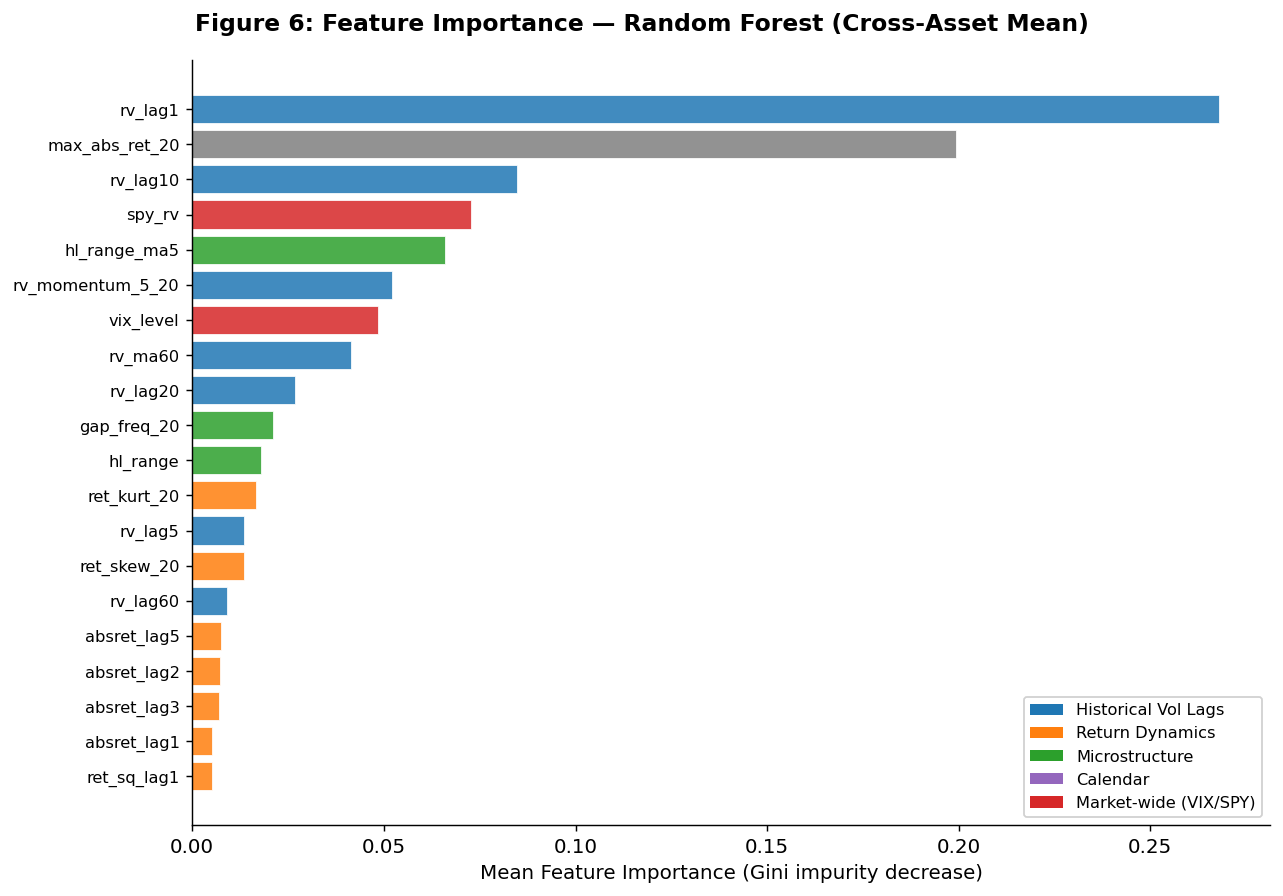

Saved → ../results/figures/fig6_feature_importance.png


In [14]:
fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('Figure 6: Feature Importance — Random Forest (Cross-Asset Mean)',
             fontsize=13, fontweight='bold')

top20 = mean_importance.head(20)

FEAT_COLORS = {
    'rv_': '#1f77b4',       # historical vol
    'ret_': '#ff7f0e',      # return dynamics
    'absret_': '#ff7f0e',
    'hl_': '#2ca02c',       # microstructure
    'volume_': '#2ca02c',
    'gap_': '#2ca02c',
    'dow_': '#9467bd',      # calendar
    'vix_': '#d62728',      # market-wide
    'spy_': '#d62728',
}
LEGEND_MAP = {
    '#1f77b4': 'Historical Vol Lags',
    '#ff7f0e': 'Return Dynamics',
    '#2ca02c': 'Microstructure',
    '#9467bd': 'Calendar',
    '#d62728': 'Market-wide (VIX/SPY)',
}

colors = []
for feat in top20.index:
    c = '#7f7f7f'
    for prefix, col in FEAT_COLORS.items():
        if feat.startswith(prefix):
            c = col
            break
    colors.append(c)

bars = ax.barh(range(len(top20)), top20.values[::-1], color=colors[::-1],
               alpha=0.85, edgecolor='white', lw=0.5)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index[::-1], fontsize=9)
ax.set_xlabel('Mean Feature Importance (Gini impurity decrease)')

from matplotlib.patches import Patch
legend_patches = [Patch(fc=c, label=l) for c, l in LEGEND_MAP.items()]
ax.legend(handles=legend_patches, fontsize=9, loc='lower right', framealpha=0.9)

plt.tight_layout()
path = os.path.join(FIGDIR, 'fig6_feature_importance.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved → {path}")

## Figure 7 — SPY: GARCH vs. ML forecasts (2018–2025)

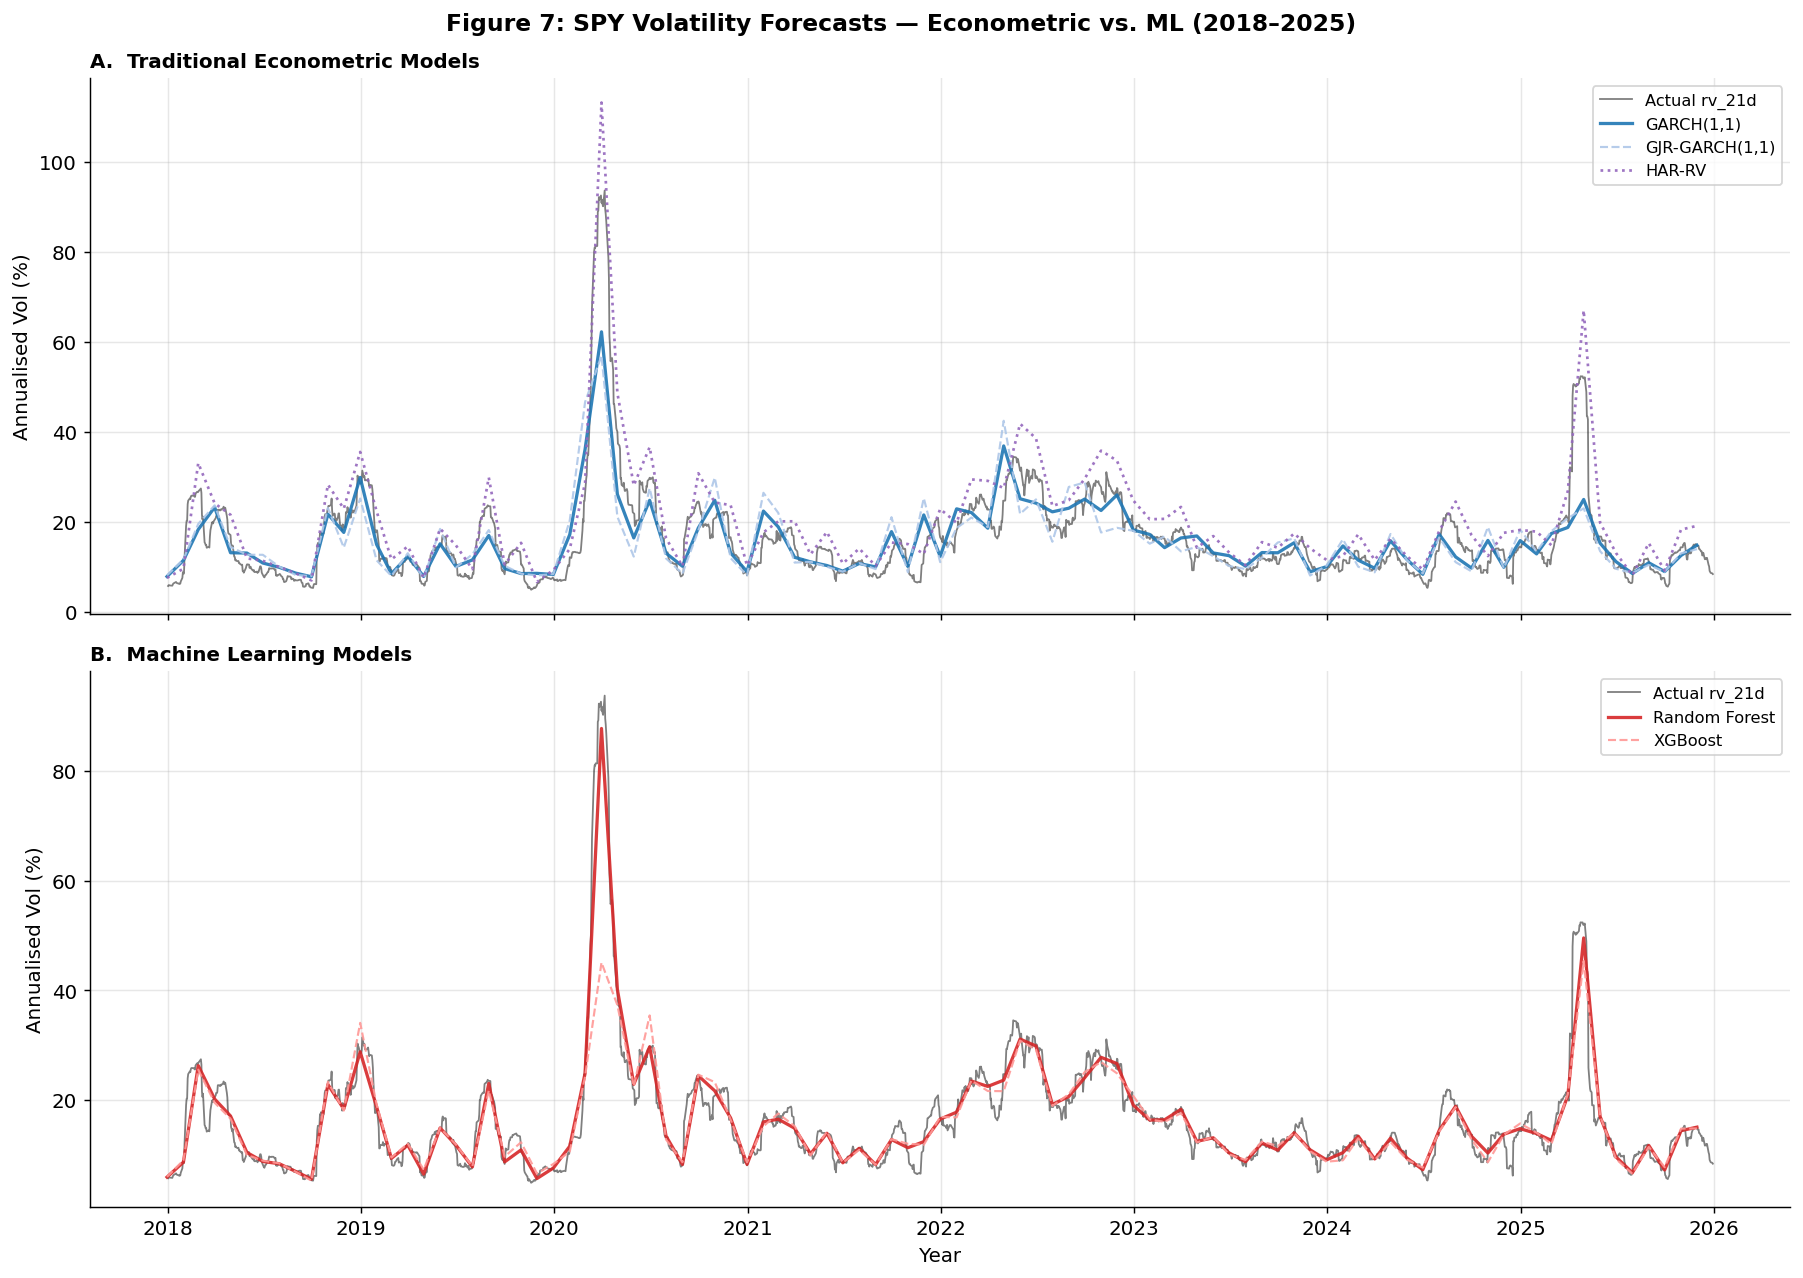

Saved → ../results/figures/fig7_ml_vs_garch_spy.png


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Figure 7: SPY Volatility Forecasts — Econometric vs. ML (2018–2025)',
             fontsize=13, fontweight='bold')

spy_rv_daily = load_and_clean('SPY', raw_dir='../data/raw')['rv_21d'].dropna().loc['2018-01-01':]

STYLE = {
    'GARCH(1,1)':     ('#1f77b4', '-',  1.8),
    'GJR-GARCH(1,1)': ('#aec7e8', '--', 1.2),
    'HAR-RV':         ('#9467bd', ':',  1.5),
    'Random Forest':  ('#d62728', '-',  1.8),
    'XGBoost':        ('#ff9896', '--', 1.2),
}

# Top panel: econometric
ax = axes[0]
ax.plot(spy_rv_daily.index, spy_rv_daily, color='black', lw=1.0, alpha=0.5,
        label='Actual rv_21d')
for name in ['GARCH(1,1)', 'GJR-GARCH(1,1)', 'HAR-RV']:
    sub = all_forecasts[name][all_forecasts[name]['ticker'] == 'SPY'].dropna(subset=['h1'])
    color, ls, lw = STYLE[name]
    ax.plot(pd.to_datetime(sub['date']), sub['h1'], ls, color=color, lw=lw,
            ms=4, alpha=0.9, label=name)
ax.set_title('A.  Traditional Econometric Models', fontsize=11, loc='left', fontweight='bold')
ax.set_ylabel('Annualised Vol (%)')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)

# Bottom panel: ML
ax = axes[1]
ax.plot(spy_rv_daily.index, spy_rv_daily, color='black', lw=1.0, alpha=0.5,
        label='Actual rv_21d')
for name in ['Random Forest', 'XGBoost']:
    sub = all_forecasts[name][all_forecasts[name]['ticker'] == 'SPY'].dropna(subset=['h1'])
    color, ls, lw = STYLE[name]
    ax.plot(pd.to_datetime(sub['date']), sub['h1'], ls, color=color, lw=lw,
            ms=4, alpha=0.9, label=name)
ax.set_title('B.  Machine Learning Models', fontsize=11, loc='left', fontweight='bold')
ax.set_ylabel('Annualised Vol (%)')
ax.set_xlabel('Year')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
path = os.path.join(FIGDIR, 'fig7_ml_vs_garch_spy.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved → {path}")

## All models vs. VIX (implied vol benchmark)

In [16]:
iv = pd.read_csv(os.path.join(PROCESSED, 'iv_monthly.csv'),
                  index_col=0, parse_dates=True)

spy_rv_raw = load_and_clean('SPY', raw_dir='../data/raw')['rv_21d'].dropna()
rv_fwd = {
    date: spy_rv_raw.loc[spy_rv_raw.index[spy_rv_raw.index > date][20]]
    for date in iv.index
    if len(spy_rv_raw.index[spy_rv_raw.index > date]) >= 21
}
rv_fwd_s = pd.Series(rv_fwd, name='rv_fwd_21d').dropna()

fc_dict_spy = {}
for name, df_m in all_forecasts.items():
    sub = df_m[df_m['ticker'] == 'SPY'].set_index('date')['h1']
    sub.index = pd.DatetimeIndex(sub.index)
    fc_dict_spy[name] = sub.reindex(rv_fwd_s.index)

tbl = forecast_vs_iv_accuracy(
    fc_dict_spy,
    iv['SPY'].reindex(rv_fwd_s.index),
    rv_fwd_s,
)
print("=== SPY: All models vs. VIX implied vol (negative diff = beats options market) ===")
display(tbl.round(3))
tbl.to_csv('../results/iv_comparison.csv')
print("\nSaved → ../results/iv_comparison.csv")

=== SPY: All models vs. VIX implied vol (negative diff = beats options market) ===


,RMSE,MAE,QLIKE,DirAcc,vs_IV_RMSE_diff
model,,,,,
"GJR-GARCH(1,1)",8.627,5.794,1.760,0.511,-0.959
"GARCH(1,1)",9.073,5.690,1.791,0.468,-0.512
"EGARCH(1,1)",9.096,5.480,1.810,0.426,-0.490
Implied Vol (VIX),9.586,6.776,2.267,0.532,0.000
LSTM,10.626,6.392,1.754,0.404,1.041
XGBoost,10.697,6.355,1.753,0.383,1.111
GARCH-XGBoost,10.761,6.434,1.871,0.404,1.175
Random Forest,11.721,6.750,1.767,0.426,2.135
GARCH-RF,12.146,7.470,2.120,0.404,2.560



Saved → ../results/iv_comparison.csv


## Residual diagnostics — ML & hybrid models

Forecast residual = actual `rv_h1` − predicted `h1`, computed on SPY (consistent with the
econometric residual diagnostics in `02_garch_baseline.ipynb`). These aren't GARCH
conditional-variance residuals, but the same white-noise check applies: if a model has
captured the predictable structure in volatility, its forecast errors should show no
remaining autocorrelation. Lag is set to 12 (not 20) since these are monthly-refit series
(~95 points), not daily residuals.

In [17]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot

ML_MODELS = ['Random Forest', 'XGBoost', 'LSTM', 'GARCH-RF', 'GARCH-XGBoost']

ml_resids: dict[str, pd.Series] = {}
for name in ML_MODELS:
    sub = all_forecasts[name]
    sub = sub[sub['ticker'] == 'SPY'].dropna(subset=['h1', 'rv_h1'])
    ml_resids[name] = pd.Series((sub['rv_h1'] - sub['h1']).values)

print("=== Ljung-Box test on forecast residuals (lag=12) ===")
print("(p < 0.05  =>  residuals still show significant autocorrelation  =>  forecast errors are predictable)")
lb_rows = []
for name, resid in ml_resids.items():
    lb = acorr_ljungbox(resid.dropna(), lags=[12], return_df=True)
    lb_rows.append({'Model': name, 'LB stat': lb['lb_stat'].iloc[0], 'p-value': lb['lb_pvalue'].iloc[0]})
lb_df = pd.DataFrame(lb_rows).set_index('Model').round(4)
display(lb_df)

=== Ljung-Box test on forecast residuals (lag=12) ===
(p < 0.05  =>  residuals still show significant autocorrelation  =>  forecast errors are predictable)


,LB stat,p-value
Model,,
Random Forest,9.4176,0.6669
XGBoost,3.8225,0.9864
LSTM,6.5417,0.8864
GARCH-RF,22.2705,0.0346
GARCH-XGBoost,3.5445,0.9903


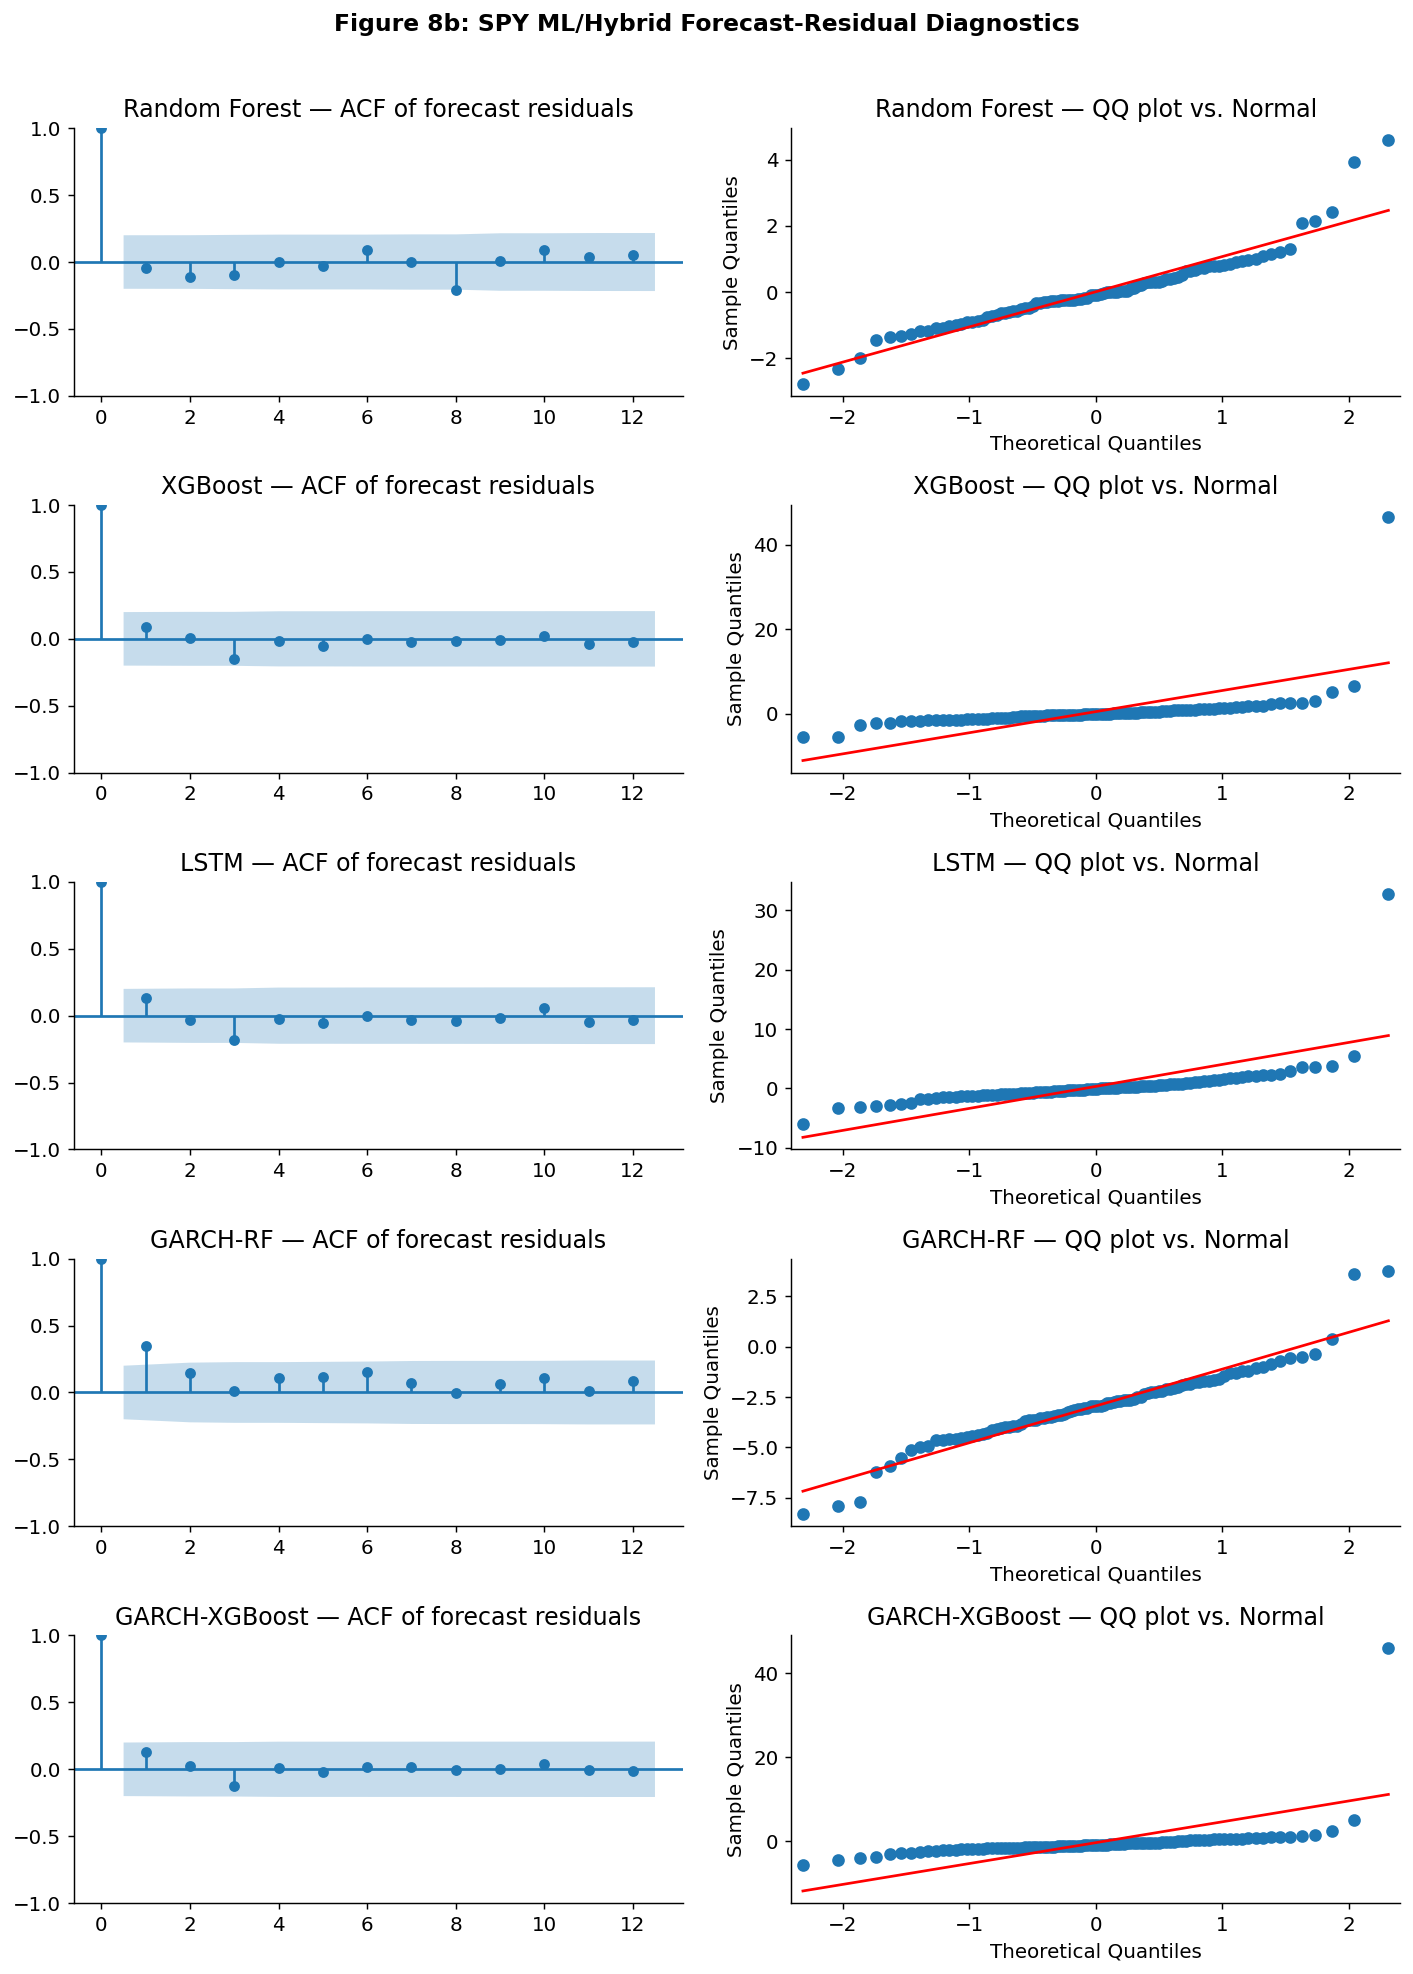

Saved → ../results/figures/fig8b_ml_residual_diagnostics.png


In [18]:
fig, axes = plt.subplots(len(ml_resids), 2, figsize=(11, 3 * len(ml_resids)))
fig.suptitle('Figure 8b: SPY ML/Hybrid Forecast-Residual Diagnostics',
             fontsize=13, fontweight='bold', y=1.01)

for i, (name, resid) in enumerate(ml_resids.items()):
    r = resid.dropna()
    plot_acf(r, lags=12, ax=axes[i, 0], title=f'{name} — ACF of forecast residuals')
    qqplot(r, line='s', ax=axes[i, 1])
    axes[i, 1].set_title(f'{name} — QQ plot vs. Normal')

plt.tight_layout()
path = os.path.join(FIGDIR, 'fig8b_ml_residual_diagnostics.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved → {path}")

## Statistical significance — Diebold-Mariano & Model Confidence Set

RMSE rankings alone don't tell us whether one model is *significantly* more accurate than
another, and comparing 9 models simultaneously raises a multiple-comparisons problem (see
`BACKTESTING_IDEAS.md` — the crypto-strategy tutorial project's brute-force feature search
produced a "Sharpe 10" model from a single test split with no correction, which shouldn't be
trusted; the same caution applies here with 9 models × 18 assets).

- **Model Confidence Set** (Hansen, Lunde & Nason 2011, via `arch.bootstrap.MCS`): pools
  squared-error losses across all 18 assets at the 1-day horizon and finds the subset of
  models that are statistically indistinguishable from the best at a 90% confidence level.
- **Diebold-Mariano**: pairwise test of each ML/hybrid model against the GARCH(1,1) baseline.

In [19]:
from src.evaluation import model_confidence_set, diebold_mariano

# Pooled squared-error loss matrix (rows = date×ticker, columns = model), 1-day horizon
# Note: some entries in all_forecasts were loaded without parse_dates (see cell above),
# so 'date' may be a string in one model and a Timestamp in another — coerce explicitly
# or the join below silently produces zero overlapping rows.
loss_frames = {}
for name, df_m in all_forecasts.items():
    sub = df_m.dropna(subset=['h1', 'rv_h1']).copy()
    sub['date'] = pd.to_datetime(sub['date'])
    sub['loss'] = (sub['h1'] - sub['rv_h1']) ** 2
    loss_frames[name] = sub.set_index(['date', 'ticker'])['loss'].rename(name)

losses_df = pd.concat(loss_frames.values(), axis=1, join='inner')
print(f"Pooled loss matrix: {losses_df.shape[0]} obs × {losses_df.shape[1]} models")

mcs_result = model_confidence_set(losses_df, size=0.10, reps=1000)
print("\n=== Model Confidence Set (90% confidence, 1-day horizon) ===")
display(mcs_result)
mcs_result.to_csv('../results/model_confidence_set.csv')
print("Saved → ../results/model_confidence_set.csv")

Pooled loss matrix: 1728 obs × 9 models

=== Model Confidence Set (90% confidence, 1-day horizon) ===


,Pvalue,in_mcs
Model name,,
Random Forest,1.000,True
LSTM,0.006,False
HAR-RV,0.006,False
GARCH-XGBoost,0.006,False
XGBoost,0.002,False
GARCH-RF,0.001,False
"EGARCH(1,1)",0.000,False
"GJR-GARCH(1,1)",0.000,False
"GARCH(1,1)",0.000,False


Saved → ../results/model_confidence_set.csv


In [20]:
print("=== Diebold-Mariano: each model vs. GARCH(1,1) baseline (1-day horizon, pooled) ===")
print("(negative DM stat => model beats GARCH(1,1); p<0.05 => difference is significant)\n")

baseline = 'GARCH(1,1)'
dm_rows = []
for name in losses_df.columns:
    if name == baseline:
        continue
    dm_stat, p_value = diebold_mariano(losses_df[name].values, losses_df[baseline].values, h=1)
    dm_rows.append({'Model': name, 'DM stat': dm_stat, 'p-value': p_value,
                    'Beats GARCH(1,1)': dm_stat < 0 and p_value < 0.05})

dm_df = pd.DataFrame(dm_rows).set_index('Model').round(4).sort_values('DM stat')
display(dm_df)
dm_df.to_csv('../results/diebold_mariano_vs_garch.csv')
print("\nSaved → ../results/diebold_mariano_vs_garch.csv")

=== Diebold-Mariano: each model vs. GARCH(1,1) baseline (1-day horizon, pooled) ===
(negative DM stat => model beats GARCH(1,1); p<0.05 => difference is significant)



,DM stat,p-value,"Beats GARCH(1,1)"
Model,,,
Random Forest,-10.1620,0.0000,True
LSTM,-1.9410,0.0523,False
GARCH-RF,-0.3545,0.7230,False
XGBoost,0.5992,0.5490,False
"EGARCH(1,1)",3.6762,0.0002,False
GARCH-XGBoost,4.3500,0.0000,False
"GJR-GARCH(1,1)",6.0709,0.0000,False
HAR-RV,16.7656,0.0000,False



Saved → ../results/diebold_mariano_vs_garch.csv
